# Movie Recommendation System

A Movie Recommendation System is a machine learning application that
suggests movies to users based on their preferences, movie characteristics,
and rating patterns.

This project uses the MovieLens dataset and implements two recommendation
approaches: Content-Based Filtering and Collaborative Filtering.

# Objectives

- Develop a movie recommendation system using machine learning.
- Recommend movies based on similar movie genres.
- Identify users with similar movie-rating patterns.
- Generate personalized movie recommendations.
- Evaluate the recommendation system using Precision@10.

### Dataset Source

The MovieLens dataset was obtained from GroupLens.
The MovieLens Small dataset contains movie information,
user ratings, genres, and other metadata.

Dataset:
MovieLens Latest Small Dataset

# Methodology

1. Dataset Collection
   - MovieLens Small dataset was used.
   - movies.csv contains movie IDs, titles, and genres.
   - ratings.csv contains user IDs, movie IDs, ratings, and timestamps.

2. Data Preprocessing
   - Loaded movie and rating datasets using Pandas.
   - Checked dataset dimensions.
   - Checked for missing values.
   - Filled missing genre values where necessary.
   - Created a user-movie rating matrix.

3. Exploratory Data Analysis
   - Analyzed rating distribution.
   - Identified the most-rated movies.
   - Identified top-rated movies using a minimum rating-count threshold.

4. Content-Based Filtering
   - Used movie genres as content features.
   - Applied TF-IDF vectorization.
   - Calculated cosine similarity.
   - Generated movie recommendations based on genre similarity.

5. Collaborative Filtering
   - Created a user-movie rating matrix.
   - Calculated user-to-user cosine similarity.
   - Identified users with similar rating patterns.
   - Recommended highly-rated movies from similar users.

6. Evaluation
   - Split the ratings into training and testing datasets.
   - Evaluated the recommendation system using Precision@10.

In [43]:
from google.colab import files

uploaded = files.upload()

Saving ml-latest-small.zip to ml-latest-small (1).zip


In [44]:
import zipfile
import os

zip_path = "/content/ml-latest-small.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [45]:
import pandas as pd

movies = pd.read_csv("/content/ml-latest-small/movies.csv")
ratings = pd.read_csv("/content/ml-latest-small/ratings.csv")

print("Movies dataset:")
display(movies.head())

print("\nRatings dataset:")
display(ratings.head())

Movies dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [46]:
print("Movies dataset shape:", movies.shape)
print("Ratings dataset shape:", ratings.shape)

Movies dataset shape: (9742, 3)
Ratings dataset shape: (100836, 4)


In [47]:
print("Missing values in Movies:")
print(movies.isnull().sum())

print("\nMissing values in Ratings:")
print(ratings.isnull().sum())

Missing values in Movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [48]:
print("Rating distribution:")
print(ratings['rating'].value_counts().sort_index())

Rating distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [49]:
print("Number of users:", ratings['userId'].nunique())
print("Number of movies:", ratings['movieId'].nunique())

Number of users: 610
Number of movies: 9724


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [51]:
movies['genres'] = movies['genres'].fillna('')

tfidf = TfidfVectorizer(token_pattern=r'[^|]+')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 20)


In [52]:
cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9742, 9742)


In [53]:
indices = pd.Series(
    movies.index,
    index=movies['title']
).drop_duplicates()

def recommend_movies(title, num_movies=10):

    if title not in indices:
        return "Movie not found. Please check the title."

    idx = indices[title]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:num_movies+1]

    movie_indices = [i[0] for i in similarity_scores]

    return movies.iloc[movie_indices][
        ['title', 'genres']
    ]

In [54]:
recommend_movies("Toy Story (1995)")

,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


In [55]:
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("User-Movie Matrix Shape:", user_movie_matrix.shape)

User-Movie Matrix Shape: (610, 9724)


In [56]:
user_movie_filled = user_movie_matrix.fillna(0)

print(user_movie_filled.shape)

(610, 9724)


In [57]:
user_movie_filled = user_movie_matrix.fillna(0)

print(user_movie_filled.shape)

(610, 9724)


In [58]:
user_id = 1

user_index = user_movie_matrix.index.get_loc(user_id)

similar_users = list(
    enumerate(user_similarity[user_index])
)

similar_users = sorted(
    similar_users,
    key=lambda x: x[1],
    reverse=True
)

print("Most similar users to User 1:")

for index, score in similar_users[1:6]:
    print(
        "User:", user_movie_matrix.index[index],
        "Similarity:", round(score, 3)
    )

Most similar users to User 1:
User: 266 Similarity: 0.357
User: 313 Similarity: 0.352
User: 368 Similarity: 0.345
User: 57 Similarity: 0.345
User: 91 Similarity: 0.335


In [59]:
def collaborative_recommend(user_id, num_movies=10):

    # Find user's position
    user_index = user_movie_matrix.index.get_loc(user_id)

    # Get similarity scores
    similarity_scores = list(
        enumerate(user_similarity[user_index])
    )

    # Sort users by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Select top 10 similar users
    similar_user_indices = [
        x[0] for x in similarity_scores[1:11]
    ]

    similar_user_ids = [
        user_movie_matrix.index[i]
        for i in similar_user_indices
    ]

    # Ratings from similar users
    similar_users_ratings = ratings[
        ratings['userId'].isin(similar_user_ids)
    ]

    # Remove movies already rated by the target user
    already_rated = ratings[
        ratings['userId'] == user_id
    ]['movieId'].tolist()

    recommendations = similar_users_ratings[
        ~similar_users_ratings['movieId'].isin(already_rated)
    ]

    # Calculate average rating
    recommendations = recommendations.groupby(
        'movieId'
    )['rating'].mean().reset_index()

    recommendations = recommendations.sort_values(
        'rating',
        ascending=False
    ).head(num_movies)

    # Add movie names
    recommendations = recommendations.merge(
        movies,
        on='movieId'
    )

    return recommendations[
        ['title', 'genres', 'rating']
    ]

In [60]:
collaborative_recommend(1, 10)

,title,genres,rating
0,Ocean's Thirteen (2007),Crime|Thriller,5.0
1,Chocolat (2000),Drama|Romance,5.0
2,"River Runs Through It, A (1992)",Drama,5.0
3,"Dude, Where's My Car? (2000)",Comedy|Sci-Fi,5.0
4,"Legend of Drunken Master, The (Jui kuen II) (1...",Action|Comedy,5.0
5,Reform School Girls (1986),Action|Drama,5.0
6,Phantasm II (1988),Action|Fantasy|Horror|Sci-Fi|Thriller,5.0
7,Moulin Rouge (2001),Drama|Musical|Romance,5.0
8,Lara Croft: Tomb Raider (2001),Action|Adventure,5.0
9,Interiors (1978),Drama,5.0


In [61]:
def final_recommendations(user_id, movie_title, num_movies=10):

    # Content-based recommendations
    content_recs = recommend_movies(movie_title, num_movies)

    # Collaborative recommendations
    collaborative_recs = collaborative_recommend(
        user_id, num_movies
    )

    print("======================================")
    print("       MOVIE RECOMMENDATION SYSTEM")
    print("======================================")

    print("\n🎬 Based on Movie You Like:")
    display(content_recs)

    print("\n👥 Based on Similar Users:")
    display(collaborative_recs)

    return content_recs, collaborative_recs

In [62]:
content_recs, collaborative_recs = final_recommendations(
    user_id=1,
    movie_title="Toy Story (1995)",
    num_movies=10
)

       MOVIE RECOMMENDATION SYSTEM

🎬 Based on Movie You Like:


,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy



👥 Based on Similar Users:


,title,genres,rating
0,Ocean's Thirteen (2007),Crime|Thriller,5.0
1,Chocolat (2000),Drama|Romance,5.0
2,"River Runs Through It, A (1992)",Drama,5.0
3,"Dude, Where's My Car? (2000)",Comedy|Sci-Fi,5.0
4,"Legend of Drunken Master, The (Jui kuen II) (1...",Action|Comedy,5.0
5,Reform School Girls (1986),Action|Drama,5.0
6,Phantasm II (1988),Action|Fantasy|Horror|Sci-Fi|Thriller,5.0
7,Moulin Rouge (2001),Drama|Musical|Romance,5.0
8,Lara Croft: Tomb Raider (2001),Action|Adventure,5.0
9,Interiors (1978),Drama,5.0


In [63]:
import matplotlib.pyplot as plt

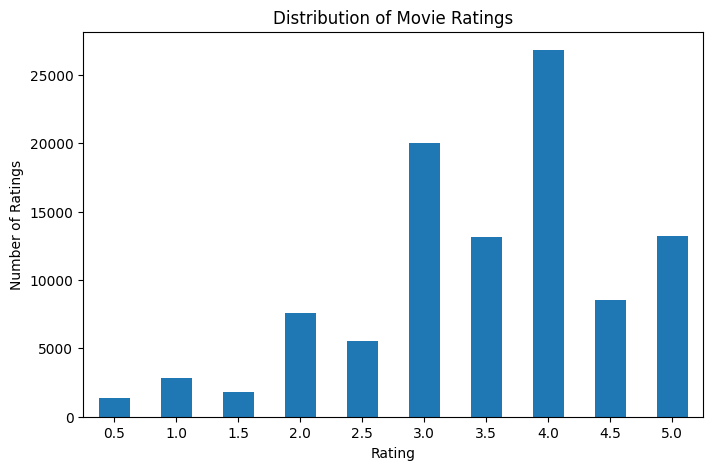

In [64]:
plt.figure(figsize=(8,5))

ratings['rating'].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.xticks(rotation=0)

plt.show()

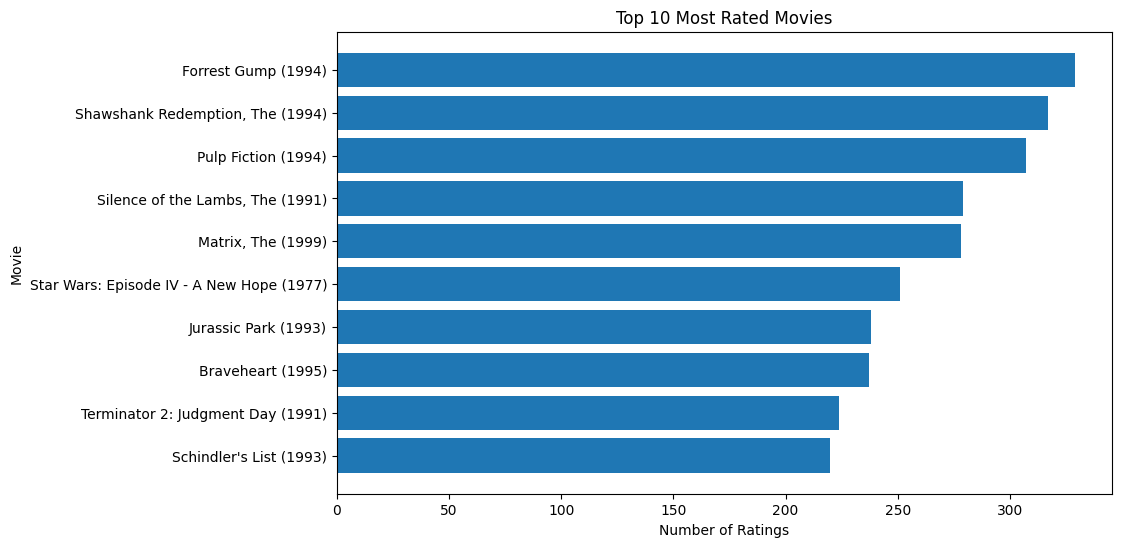

In [65]:
most_rated = ratings['movieId'].value_counts().head(10)

most_rated = most_rated.reset_index()

most_rated.columns = ['movieId', 'number_of_ratings']

most_rated = most_rated.merge(
    movies,
    on='movieId'
)

plt.figure(figsize=(10,6))

plt.barh(
    most_rated['title'],
    most_rated['number_of_ratings']
)

plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.title("Top 10 Most Rated Movies")

plt.gca().invert_yaxis()

plt.show()

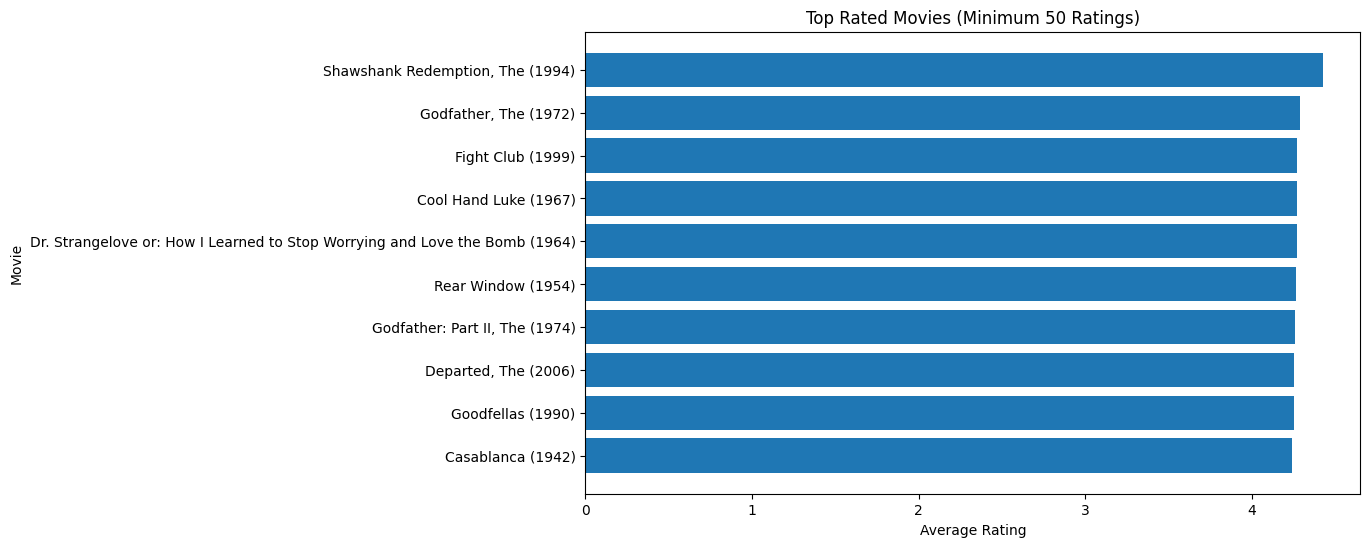

In [66]:
average_ratings = ratings.groupby(
    'movieId'
)['rating'].mean().reset_index()

average_ratings.columns = [
    'movieId',
    'average_rating'
]

rating_counts = ratings.groupby(
    'movieId'
).size().reset_index(name='rating_count')

average_ratings = average_ratings.merge(
    rating_counts,
    on='movieId'
)

# Only consider movies with at least 50 ratings
popular_movies = average_ratings[
    average_ratings['rating_count'] >= 50
]

top_rated = popular_movies.sort_values(
    'average_rating',
    ascending=False
).head(10)

top_rated = top_rated.merge(
    movies,
    on='movieId'
)

plt.figure(figsize=(10,6))

plt.barh(
    top_rated['title'],
    top_rated['average_rating']
)

plt.xlabel("Average Rating")
plt.ylabel("Movie")
plt.title("Top Rated Movies (Minimum 50 Ratings)")

plt.gca().invert_yaxis()

plt.show()

In [67]:
def precision_at_k(user_id, k=10, rating_threshold=4.0):

    # Movies the user actually rated highly
    actual = ratings[
        (ratings['userId'] == user_id) &
        (ratings['rating'] >= rating_threshold)
    ]['movieId'].tolist()

    # Get recommendations
    recommendations = collaborative_recommend(
        user_id, k
    )

    # Get movie IDs of recommendations
    recommended_titles = recommendations['title'].tolist()

    recommended_ids = movies[
        movies['title'].isin(recommended_titles)
    ]['movieId'].tolist()

    # Count relevant recommendations
    relevant = len(
        set(recommended_ids) & set(actual)
    )

    precision = relevant / k

    return precision

In [68]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", len(train_ratings))
print("Testing ratings:", len(test_ratings))

Training ratings: 80668
Testing ratings: 20168


In [69]:
train_matrix = train_ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

train_matrix_filled = train_matrix.fillna(0)

train_similarity = cosine_similarity(
    train_matrix_filled
)

print("Training matrix:", train_matrix.shape)
print("Similarity matrix:", train_similarity.shape)

Training matrix: (610, 8983)
Similarity matrix: (610, 610)


In [70]:
def evaluate_recommendations(user_id, k=10):

    if user_id not in train_matrix.index:
        return []

    user_index = train_matrix.index.get_loc(user_id)

    similarity_scores = list(
        enumerate(train_similarity[user_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similar_user_indices = [
        x[0] for x in similarity_scores[1:11]
    ]

    similar_user_ids = [
        train_matrix.index[i]
        for i in similar_user_indices
    ]

    # Movies already seen in training
    seen_movies = set(
        train_ratings[
            train_ratings['userId'] == user_id
        ]['movieId']
    )

    # Ratings from similar users
    similar_ratings = train_ratings[
        train_ratings['userId'].isin(similar_user_ids)
    ]

    # Only highly rated movies
    similar_ratings = similar_ratings[
        similar_ratings['rating'] >= 4
    ]

    # Remove movies already seen
    recommendations = similar_ratings[
        ~similar_ratings['movieId'].isin(seen_movies)
    ]

    recommendations = (
        recommendations
        .groupby('movieId')['rating']
        .mean()
        .sort_values(ascending=False)
        .head(k)
    )

    return recommendations.index.tolist()

In [71]:
def calculate_precision(user_id, k=10):

    recommended_movies = evaluate_recommendations(
        user_id, k
    )

    actual_movies = set(
        test_ratings[
            (test_ratings['userId'] == user_id) &
            (test_ratings['rating'] >= 4)
        ]['movieId']
    )

    if len(recommended_movies) == 0:
        return 0

    relevant_movies = (
        set(recommended_movies) &
        actual_movies
    )

    precision = len(relevant_movies) / len(
        recommended_movies
    )

    return precision

In [72]:
import numpy as np

In [73]:
precisions = []

for user_id in test_ratings['userId'].unique():

    precision = calculate_precision(
        user_id, 10
    )

    precisions.append(precision)

average_precision = np.mean(precisions)

print("Average Precision@10:", round(
    average_precision, 4
))

Average Precision@10: 0.0226


In [74]:
print("Movie Recommendation System Evaluation")
print("---------------------------------------")
print("Evaluation Metric : Precision@10")
print("Average Precision@10:", round(average_precision, 4))
print("Percentage:", round(average_precision * 100, 2), "%")

Movie Recommendation System Evaluation
---------------------------------------
Evaluation Metric : Precision@10
Average Precision@10: 0.0226
Percentage: 2.26 %


In [75]:
movie_name = input("Enter a movie name: ")

matches = movies[
    movies['title'].str.contains(
        movie_name,
        case=False,
        na=False
    )
]

if len(matches) == 0:
    print("Movie not found. Please try another movie.")

else:
    selected_movie = matches.iloc[0]['title']

    print("\nSelected movie:", selected_movie)
    print("\nRecommended Movies:")

    display(
        recommend_movies(selected_movie, 10)
    )

Enter a movie name: Toy Story

Selected movie: Toy Story (1995)

Recommended Movies:


,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


# Conclusion

The Movie Recommendation System successfully combines content-based
filtering and collaborative filtering to generate movie recommendations.

The content-based approach recommends movies with similar genres, while
the collaborative filtering approach recommends movies based on the
preferences of similar users.

The system achieved an Average Precision@10 of 0.0226 on the held-out
test dataset.